In [3]:
import pandas as pd

In [4]:
import numpy as np

In [5]:
import seaborn as sns

## Understanding the data


In [6]:
df=pd.read_csv("ApexCare_General_Hospital - Sheet1.csv")
df.head()

,Age,Gender,Blood Type,Medical Condition,Date of Admission,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Test Results,Admission Year
0,52,Female,O+,Asthma,4/2/2021,Cigna,17895.23,369,Elective,4/22/2021,Abnormal,2021
1,56,Male,O+,Obesity,3/31/2020,Aetna,33399.51,162,Emergency,3/25/2020,Abnormal,2020
2,74,Female,B-,Arthritis,8/25/2020,Blue Cross,21886.40,372,Elective,9/10/2020,Normal,2020
3,86,Male,O-,Cancer,1/14/2024,UnitedHealthcare,45417.88,410,Urgent,2/18/2024,Normal,2024
4,60,Male,A-,Obesity,7/14/2022,Aetna,49467.81,130,Emergency,7/11/2022,Abnormal,2022


In [7]:
df.tail()

,Age,Gender,Blood Type,Medical Condition,Date of Admission,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Test Results,Admission Year
4994,62,Male,AB-,Asthma,6/12/2022,UnitedHealthcare,2151.65,493,Emergency,8/4/2022,Abnormal,2022
4995,19,Male,O-,Cancer,7/31/2022,Aetna,13834.44,153,Elective,7/28/2022,Normal,2022
4996,36,Female,B-,Asthma,11/26/2022,Cigna,28613.03,376,Emergency,12/26/2022,Abnormal,2022
4997,48,Male,A+,Hypertension,5/11/2021,Aetna,39632.66,304,Elective,5/27/2021,Inconclusive,2021
4998,65,Male,O-,Hypertension,12/23/2022,Cigna,32519.22,445,Elective,2/2/2023,Abnormal,2022


In [8]:
## to check numbers of rows and columns we use shape
df.shape

(4999, 12)

## Describe is use for statisticsl summary


In [9]:
df.describe()

,Age,Billing Amount,Room Number,Admission Year
count,4999.000000,4999.00000,4999.000000,4999.000000
mean,50.393479,25294.65894,301.359272,2021.326065
std,17.285280,15652.20462,116.403789,1.485323
min,13.000000,6.11000,101.000000,2019.000000
25%,38.000000,11625.84000,202.000000,2020.000000
50%,50.000000,24982.67000,301.000000,2021.000000
75%,64.000000,38987.45000,403.000000,2023.000000
max,88.000000,52760.52000,499.000000,2024.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 4999 non-null   int64  
 1   Gender              4999 non-null   object 
 2   Blood Type          4999 non-null   object 
 3   Medical Condition   4999 non-null   object 
 4   Date of Admission   4999 non-null   object 
 5   Insurance Provider  4999 non-null   object 
 6   Billing Amount      4999 non-null   float64
 7   Room Number         4999 non-null   int64  
 8   Admission Type      4999 non-null   object 
 9   Discharge Date      4999 non-null   object 
 10  Test Results        4999 non-null   object 
 11  Admission Year      4999 non-null   int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 468.8+ KB


In [11]:
## converting date type
df["Date of Admission"]=pd.to_datetime(df["Date of Admission"])
df["Discharge Date"]=pd.to_datetime(df["Discharge Date"])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Age                 4999 non-null   int64         
 1   Gender              4999 non-null   object        
 2   Blood Type          4999 non-null   object        
 3   Medical Condition   4999 non-null   object        
 4   Date of Admission   4999 non-null   datetime64[ns]
 5   Insurance Provider  4999 non-null   object        
 6   Billing Amount      4999 non-null   float64       
 7   Room Number         4999 non-null   int64         
 8   Admission Type      4999 non-null   object        
 9   Discharge Date      4999 non-null   datetime64[ns]
 10  Test Results        4999 non-null   object        
 11  Admission Year      4999 non-null   int64         
dtypes: datetime64[ns](2), float64(1), int64(3), object(6)
memory usage: 468.8+ KB


## data cleaning


In [13]:
duplicate=df.duplicated().sum()
print(duplicate)

0


In [14]:
! pip install matplotlib as plt

ERROR: Could not find a version that satisfies the requirement as (from versions: none)
ERROR: No matching distribution found for as


In [15]:
! pip install seaborn as sns

ERROR: Could not find a version that satisfies the requirement as (from versions: none)
ERROR: No matching distribution found for as


In [16]:
import matplotlib as plt
import seaborn as sns

## checking for null

In [17]:
df.isnull().sum()

Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Test Results          0
Admission Year        0
dtype: int64

In [18]:
##  creating length of stay
df["Length of stay"]=(df["Discharge Date"] - df["Date of Admission"]).dt.days

In [19]:
df.head()

,Age,Gender,Blood Type,Medical Condition,Date of Admission,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Test Results,Admission Year,Length of stay
0,52,Female,O+,Asthma,2021-04-02,Cigna,17895.23,369,Elective,2021-04-22,Abnormal,2021,20
1,56,Male,O+,Obesity,2020-03-31,Aetna,33399.51,162,Emergency,2020-03-25,Abnormal,2020,-6
2,74,Female,B-,Arthritis,2020-08-25,Blue Cross,21886.40,372,Elective,2020-09-10,Normal,2020,16
3,86,Male,O-,Cancer,2024-01-14,UnitedHealthcare,45417.88,410,Urgent,2024-02-18,Normal,2024,35
4,60,Male,A-,Obesity,2022-07-14,Aetna,49467.81,130,Emergency,2022-07-11,Abnormal,2022,-3


In [20]:
df[df["Length of stay"] < 0][
    ["Date of Admission", "Discharge Date", "Length of stay"]
]

,Date of Admission,Discharge Date,Length of stay
1,2020-03-31,2020-03-25,-6
4,2022-07-14,2022-07-11,-3
11,2020-03-11,2020-02-25,-15
23,2020-05-25,2020-05-09,-16
25,2021-04-20,2021-03-28,-23
...,...,...,...
4953,2019-10-20,2019-10-07,-13
4969,2020-09-09,2020-09-02,-7
4985,2020-05-23,2020-05-10,-13
4992,2020-07-01,2020-06-28,-3


Replacing negative value with NAN

In [21]:
df.loc[df["Length of stay"]<0,"Length of stay"]=np.nan

In [22]:
df

,Age,Gender,Blood Type,Medical Condition,Date of Admission,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Test Results,Admission Year,Length of stay
0,52,Female,O+,Asthma,2021-04-02,Cigna,17895.23,369,Elective,2021-04-22,Abnormal,2021,20.0
1,56,Male,O+,Obesity,2020-03-31,Aetna,33399.51,162,Emergency,2020-03-25,Abnormal,2020,NaN
2,74,Female,B-,Arthritis,2020-08-25,Blue Cross,21886.40,372,Elective,2020-09-10,Normal,2020,16.0
3,86,Male,O-,Cancer,2024-01-14,UnitedHealthcare,45417.88,410,Urgent,2024-02-18,Normal,2024,35.0
4,60,Male,A-,Obesity,2022-07-14,Aetna,49467.81,130,Emergency,2022-07-11,Abnormal,2022,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,62,Male,AB-,Asthma,2022-06-12,UnitedHealthcare,2151.65,493,Emergency,2022-08-04,Abnormal,2022,53.0
4995,19,Male,O-,Cancer,2022-07-31,Aetna,13834.44,153,Elective,2022-07-28,Normal,2022,NaN
4996,36,Female,B-,Asthma,2022-11-26,Cigna,28613.03,376,Emergency,2022-12-26,Abnormal,2022,30.0
4997,48,Male,A+,Hypertension,2021-05-11,Aetna,39632.66,304,Elective,2021-05-27,Inconclusive,2021,16.0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Age                 4999 non-null   int64         
 1   Gender              4999 non-null   object        
 2   Blood Type          4999 non-null   object        
 3   Medical Condition   4999 non-null   object        
 4   Date of Admission   4999 non-null   datetime64[ns]
 5   Insurance Provider  4999 non-null   object        
 6   Billing Amount      4999 non-null   float64       
 7   Room Number         4999 non-null   int64         
 8   Admission Type      4999 non-null   object        
 9   Discharge Date      4999 non-null   datetime64[ns]
 10  Test Results        4999 non-null   object        
 11  Admission Year      4999 non-null   int64         
 12  Length of stay      4093 non-null   float64       
dtypes: datetime64[ns](2), float64(2), int64(3), obje

In [24]:
df.describe()

,Age,Date of Admission,Billing Amount,Room Number,Discharge Date,Admission Year,Length of stay
count,4999.000000,4999,4999.00000,4999.000000,4999,4999.000000,4093.000000
mean,50.393479,2021-11-01 08:01:37.939588096,25294.65894,301.359272,2021-11-16 21:05:26.225244928,2021.326065,21.172245
min,13.000000,2019-05-08 00:00:00,6.11000,101.000000,2019-05-09 00:00:00,2019.000000,0.000000
25%,38.000000,2020-08-08 00:00:00,11625.84000,202.000000,2020-08-15 00:00:00,2020.000000,9.000000
50%,50.000000,2021-11-02 00:00:00,24982.67000,301.000000,2021-11-19 00:00:00,2021.000000,21.000000
75%,64.000000,2023-01-31 12:00:00,38987.45000,403.000000,2023-02-24 00:00:00,2023.000000,31.000000
max,88.000000,2024-05-06 00:00:00,52760.52000,499.000000,2024-06-05 00:00:00,2024.000000,87.000000
std,17.285280,NaN,15652.20462,116.403789,NaN,1.485323,13.948652


### Data Analysis

In [25]:
### Admission type analysis
df["Admission Type"].value_counts()


Admission Type
Elective     1719
Urgent       1653
Emergency    1627
Name: count, dtype: int64

## Visualizing Admission type Analysis

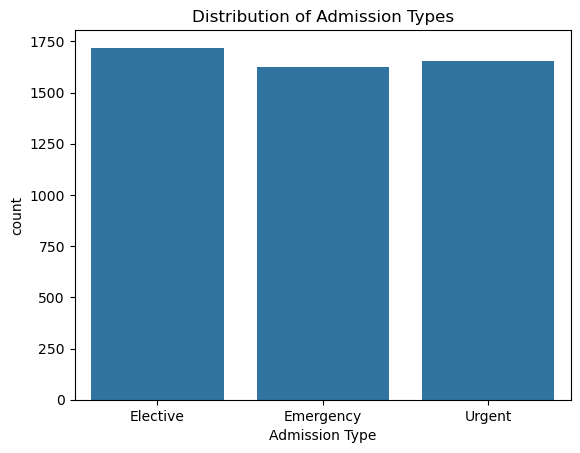

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure()
sns.countplot(data=df, x="Admission Type")
plt.title("Distribution of Admission Types")
plt.show()

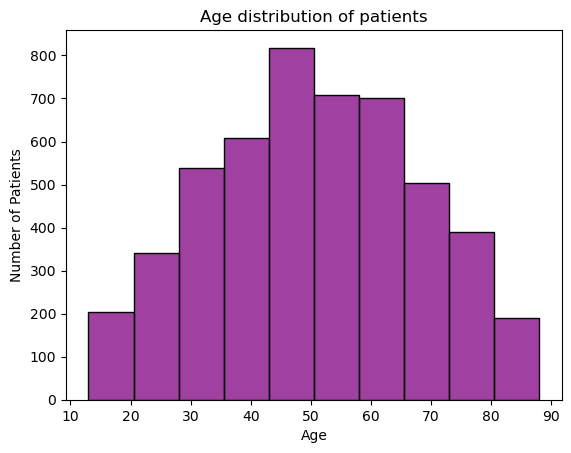

In [33]:
# Age distribution analysis using histogram note:sns=seaborn
plt.figure()              #create a new figure
sns.histplot(df["Age"], bins=10,color="purple")   # plot age distribution
plt.title("Age distribution of patients") # set the title
plt.xlabel("Age")       # label x-axis
plt.ylabel("Number of Patients") # label y-axis
plt.savefig("Age Distribution Of Patients.png") #save the plot as png file
plt.show() # Display the plot

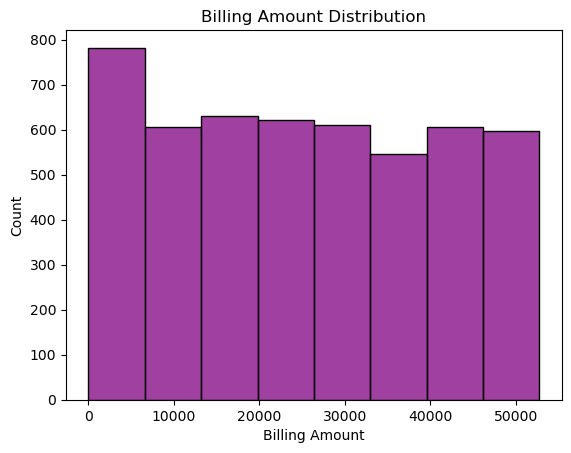

In [37]:
## Billing Amount Distribution
plt.Figure()
sns.histplot(df["Billing Amount"], bins=8, color="purple")
plt.title("Billing Amount Distribution")
plt.xlabel("Billing Amount")
plt.savefig("Billing Amount Distribution.png")
plt.show()

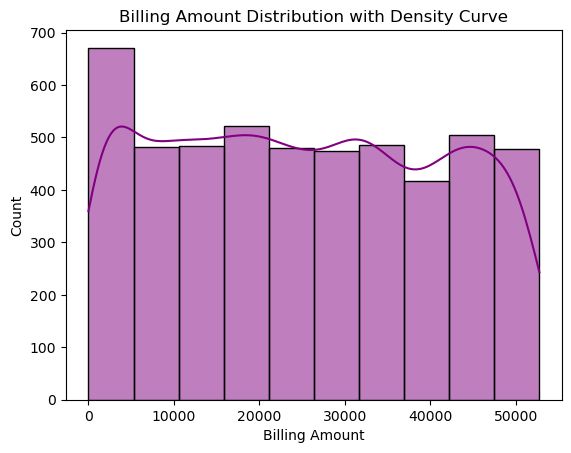

In [39]:
## Adding a KDE
plt.Figure()
sns.histplot(df["Billing Amount"],bins=10,color="purple", kde=True)
plt.title("Billing Amount Distribution with Density Curve")
plt.xlabel("Billing Amount")
plt.savefig("Billing Amount Distribution With Density Curve.png")
plt.show()

In [40]:
# Medical condition Analysis
df["Medical Condition"].value_counts()

Medical Condition
Diabetes        855
Obesity         847
Asthma          832
Cancer          824
Hypertension    823
Arthritis       818
Name: count, dtype: int64

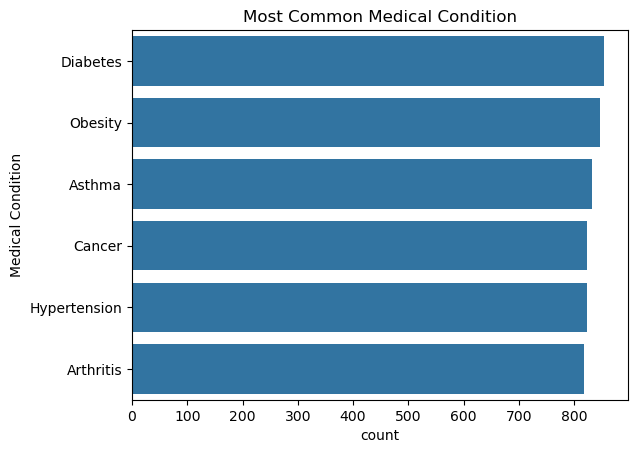

In [44]:
plt.Figure()  # create new fig
sns.countplot(data=df,y="Medical Condition", # plot count of medical condition
              order=df["Medical Condition"].value_counts().index) #  order bars by fig
plt.title("Most Common Medical Condition") # set title
plt.savefig("Most Common Medical Condition.png") # save plot as png file
plt.show()  # display the plot

## Boxplot
A boxplot was used to visualize the distribution of hospital stay length and total stays

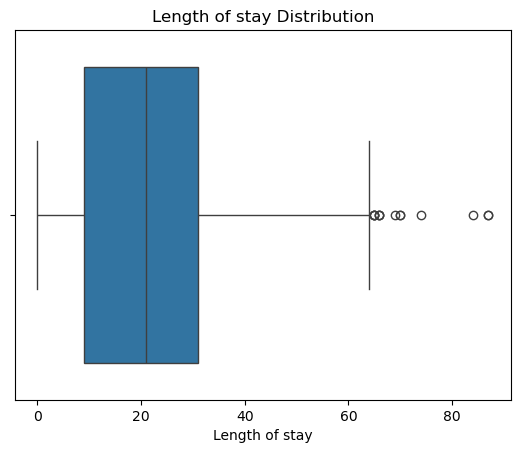

In [45]:
plt.Figure()      # create new figure
sns.boxplot(x=df["Length of stay"])   # visualize the distribution in boxplot
plt.title("Length of stay Distribution")  # set a title
plt.savefig("Length of stay Distribution.png") #saving as png file
plt.show() # display the plot

## Average billing amount by insurance providers
This shows the average billing amount for each insurance provider,sorted from highest to lowest.it also shows which providers are associated with higher or lower chargers,making comparisons easier and support decision when choosing an insurance provider

In [52]:
# insurance provider analysis 
df.groupby("Insurance Provider")["Billing Amount"].mean()\
     .sort_values(ascending=False) \
    .round(2) # calculate and display the average billing amount per insurance provider

Insurance Provider
Medicare            26221.45
Aetna               25586.15
Cigna               25368.55
Blue Cross          24600.81
UnitedHealthcare    24595.69
Name: Billing Amount, dtype: float64

## Count of Test Results
This shows the frequency of each unique test result in the dataset.it useful for quicky results common.

In [54]:
df["Test Results"].value_counts() # count the number of occurrences for each test results 

Test Results
Inconclusive    1705
Normal          1680
Abnormal        1614
Name: count, dtype: int64